# Land BGC — alternate spin-ups vs Full-CPL

Figures:
* `FullCPL_vs_FOSI_land_spinup.pdf`

**Setup** holds everything you normally change: paths, the experiment table, labels, colors and years. Each analysis step then has a **settings** cell (its parameters and plot style) and a **compute & plot** cell that calls the shared classes in `../util/` directly. Figures are saved to `FIG_DIR` (public_html) and cached/derived data to `DATA_DIR` (public_html `data/`, indexed in `data/README.md`).

In [1]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

import os 
import re, string
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
try:
    import cftime  # optional for no-leap calendars
except Exception:
    cftime = None

from util.experiments import build_exp_subdirs_from_run_dict, make_run_dict
from util.figures import publish
from util.land_bgc import LandCompareStability

## Setup

In [2]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/land_compare"
DATA_DIR     = f"{OUTPUT_ROOT}/data/land"                  # cached/derived data (index: data/README.md)
OBS_DIR      = f"{OUTPUT_ROOT}/data/obs"                                          # HadSST Nino3.4 reference

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG3": {
        "spin-up":   {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-2000"},
        "piControl": {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-0500"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}

# ---- analysis settings ----
EXPS        = ["Full-CPL", "AltBG1", "AltBG2"]   # experiments compared (plotting order)


In [3]:
# Shared inputs/outputs
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/land_compare
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/land_compare


## 1 Land spin-up comparison
### Settings

In [4]:
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
land_file   = f"{OUTPUT_ROOT}/data/land_mask/landmask.nc"
fig_dir     = FIG_DIR
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# =========================================================
# --- EXPERIMENT METADATA ---
# =========================================================
exp_tags  = EXPS
labels    = [LABEL[t] for t in EXPS]
time_strs = ["0221-0350", "0221-0350", "0221-0350"]
calendar  = "noleap"

exp_subdirs = {
    "20231209.v3.LR.piControl-spinup.chrysalis":      "post/time_series/lnd",
    "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis": "post/time_series/lnd",
    "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis": "post/time_series/lnd",
}
exps = list(exp_subdirs.keys())

# =========================================================
# --- REGION & TIME SETTINGS ---
# =========================================================
region_index           = 0
annual_hist            = False
verbose                = True
force_fromspan         = True
time_anchor            = "start"
month_index_correction = "shift_back_1"  # or "auto"

var_dict_fullcpl = [
    ("TOTECOSYSC", (2900, 2960)),
    ("TOTSOMC", (2030, 2070)),
    ("TOTVEGC", (710, 750)),
    ("GPP", (60, 180)),
    ("HTOP", (6.3, 6.6)),
    ("TWS", (9.3, 9.45)),
    ("TLAI", (1.0, 1.70)),
    ("H2OSNO", (90, 140)),
    ("TSOI_10CM", (4, 16)),
    ("SOILWATER_10CM", (28, 37)),
    ("HCSOI", (19.15, 19.35)),
    ("FSH", (20, 45)),
]

# =========================================================
# --- PLOTTING CONTROLS ---
# =========================================================
exp_indices  = [0, 1, 2]
subper       = 1
legend_loc   = "best"
fontz        = 28.0
figsize      = (40, 20)
overwrite    = False

x_step     = 20.0      # coarser ticks on 2001–2500
x_min      = 218
x_max      = 353


# running mean / variability controls
band_alpha       = 0.20
sigma_mult       = 1.0        # ±1σ envelope
filt_window      = 12         # 36-month centered window
filter_mode      = "raw"      # or "deseasoned"
show_monthly     = False      # faint monthly trace
show_filtered    = True       # thick mean line
show_variability = True       # shaded ±σ band
force_recompute  = False      # set True to regenerate figdata
save_fmt         = "nc"       # "nc", "csv", or "both"


### Compute & plot

Skip existing /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/land_bgc/20231209.v3.LR.piControl-spinup.chrysalis_TOTECOSYSC_processed.nc
Skip existing /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/land_bgc/20231209.v3.LR.piControl-spinup.chrysalis_TOTSOMC_processed.nc
Skip existing /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/land_bgc/20231209.v3.LR.piControl-spinup.chrysalis_TOTVEGC_processed.nc
Skip existing /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/land_bgc/20231209.v3.LR.piControl-spinup.chrysalis_TLAI_processed.nc
Skip existing /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/land_bgc/20231209.v3.LR.piControl-spinup.chrysalis_GPP_processed.nc
Skip existing /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/land_bgc/20231209.v3.LR.piControl-spinup.chrysalis_TWS_processed.nc
Skip e

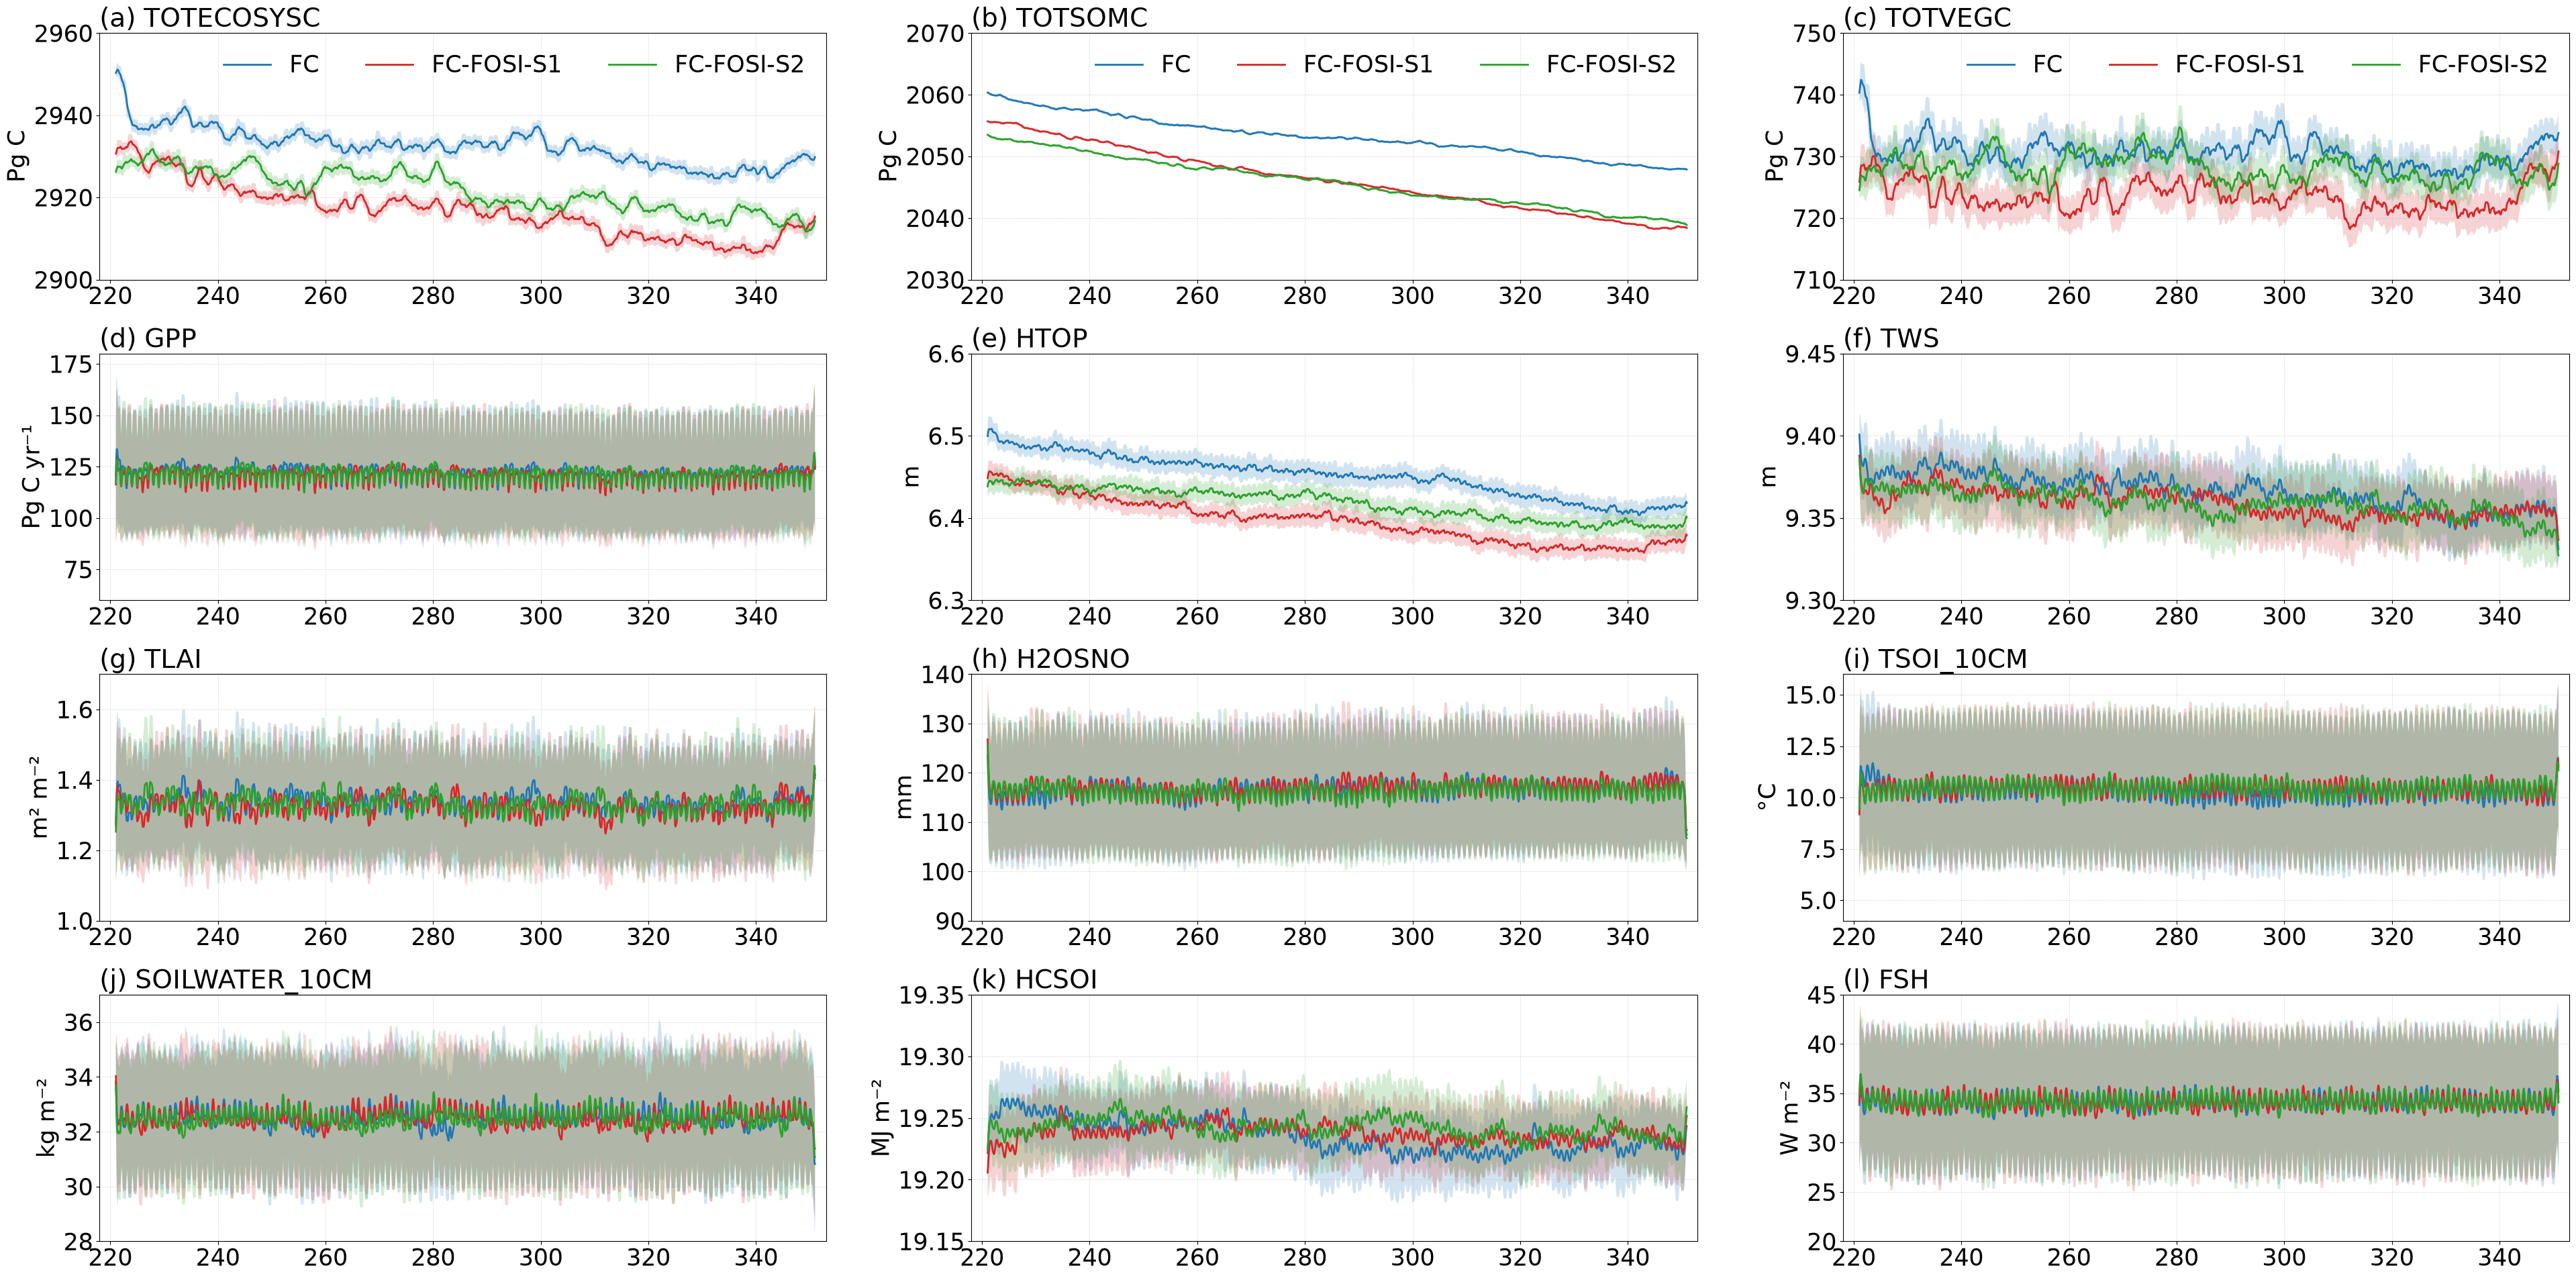

[ok] Wrote /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/land_compare/fig_comparison_land_spinup.pdf
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/land_compare


In [5]:
# =========================================================
# --- INSTANTIATE ANALYZER ---
# =========================================================
stab = LandCompareStability(
    root_dir=data_dir,
    experiments=tuple(exps),
    case_ids=tuple(exp_tags),
    exp_labels=tuple(labels),
    time_strs=tuple(time_strs),
    exp_subdirs=exp_subdirs,
    annual_hist=annual_hist,
    verbose=verbose,
    force_time_from_span=force_fromspan,
    time_anchor=time_anchor,
    month_index_correction=month_index_correction,
    region_index=region_index,
    land_file=land_file,
    calendar=calendar,

    # --- plotting options ---
    show_monthly=show_monthly,
    show_filtered=show_filtered,
    show_variability=show_variability,
    filt_window_months=filt_window,
    band_alpha=band_alpha,
    sigma_mult=sigma_mult,
    filter_mode=filter_mode,
)

# =========================================================
# --- PREPROCESS (optional; ensures annual files exist) ---
# =========================================================
for ei in exp_indices:
    stab.save_processed_series(
        exp_index=ei,
        out_dir=out_dir,
        overwrite=overwrite,
    )

# =========================================================
# --- ANALYZE AND PLOT ---
# =========================================================
output_pdf = os.path.join(fig_dir, "FullCPL_vs_FOSI_land_spinup.pdf")
stab.analyze_comparison(
    exp_indices=exp_indices,
    var_dict=var_dict_fullcpl,
    subper=subper,
    fontz=fontz,
    figsize=figsize,
    legend_loc=legend_loc,
    output_pdf=output_pdf,
    save_data_dir=out_dir,      # writes/reads figdata_{VAR}.nc
    save_fmt=save_fmt,
    force_recompute=force_recompute,
    xlim=(x_min,x_max),
    xstep=x_step, 
)

print(f"[ok] Wrote {output_pdf}")

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))
